In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score

In [3]:
train = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


We check for nulls in our dataset.

In [6]:
(train.isna().sum() / len(train) * 100).sort_values(ascending=False).head(10)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
FireplaceQu     47.260274
LotFrontage     17.739726
GarageCond       5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64

In [7]:
(test.isna().sum() / len(test) * 100).sort_values(ascending=False).head(10)

PoolQC          99.794380
MiscFeature     96.504455
Alley           92.666210
Fence           80.123372
FireplaceQu     50.034270
LotFrontage     15.558602
GarageCond       5.346127
GarageQual       5.346127
GarageYrBlt      5.346127
GarageFinish     5.346127
dtype: float64

We remove the features which has null higher than 80% of the observations. They are the same for both train and test set.

In [8]:
for col in train.columns:
    if (train[col].isna().sum() / len(train[col])) > 0.80:
        train.drop(columns = col, inplace = True)
        test.drop(columns = col, inplace = True)

There are still null features. We will fill those values with modes for both numeric and categorical variables.

In [9]:
train.isna().sum().sort_values(ascending=False).head(15)

FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtFinType1     37
BsmtCond         37
BsmtQual         37
MasVnrType        8
MasVnrArea        8
Electrical        1
dtype: int64

In [10]:
test.isna().sum().sort_values(ascending=False).head(29)

FireplaceQu     730
LotFrontage     227
GarageCond       78
GarageQual       78
GarageYrBlt      78
GarageFinish     78
GarageType       76
BsmtCond         45
BsmtQual         44
BsmtExposure     44
BsmtFinType1     42
BsmtFinType2     42
MasVnrType       16
MasVnrArea       15
MSZoning          4
BsmtHalfBath      2
Utilities         2
Functional        2
BsmtFullBath      2
BsmtUnfSF         1
SaleType          1
BsmtFinSF2        1
BsmtFinSF1        1
Exterior2nd       1
Exterior1st       1
TotalBsmtSF       1
GarageCars        1
KitchenQual       1
GarageArea        1
dtype: int64

In [11]:
for col in test.iloc[:,1:].columns:
    if train[col].dtype.name == 'object':
        train[col].fillna(value='Other', inplace=True)
        test[col].fillna(value='Other', inplace=True)

In [12]:
for col in test.iloc[:,1:].columns:
    if train[col].dtype.name != 'object':
        train[col].fillna(value=0, inplace=True)
        test[col].fillna(value=0, inplace=True)

We drop the features which have the same level more than 70% of the time.

In [13]:
for col in train.columns:
    if ((train[col].value_counts()/len(train[col])) > 0.7).any() == True:
        train.drop(columns = col, inplace = True)
        test.drop(columns = col, inplace = True)

In [14]:
train.drop('Id', axis = 1, inplace=True)

# Exploratory Data Analysis

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 44 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    1460 non-null   int64  
 1   LotFrontage   1460 non-null   float64
 2   LotArea       1460 non-null   int64  
 3   LotShape      1460 non-null   object 
 4   Neighborhood  1460 non-null   object 
 5   HouseStyle    1460 non-null   object 
 6   OverallQual   1460 non-null   int64  
 7   OverallCond   1460 non-null   int64  
 8   YearBuilt     1460 non-null   int64  
 9   YearRemodAdd  1460 non-null   int64  
 10  Exterior1st   1460 non-null   object 
 11  Exterior2nd   1460 non-null   object 
 12  MasVnrType    1460 non-null   object 
 13  MasVnrArea    1460 non-null   float64
 14  ExterQual     1460 non-null   object 
 15  Foundation    1460 non-null   object 
 16  BsmtQual      1460 non-null   object 
 17  BsmtExposure  1460 non-null   object 
 18  BsmtFinType1  1460 non-null 

Correlation for numeric features.

In [16]:
train.corr().iloc[-1:,:].T.sort_values(by='SalePrice', ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


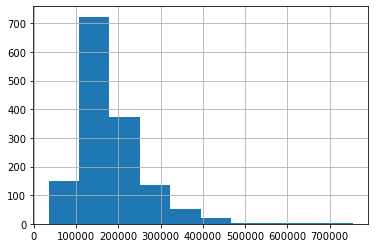

In [17]:
train.SalePrice.hist()

To make the distribution normal, we are performing a log transformation.

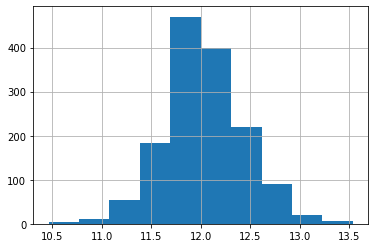

In [18]:
np.log(train.SalePrice).hist()

Now that it looks more like normal distribution, we change the SalePrice in our dataset to log of SalePrice.

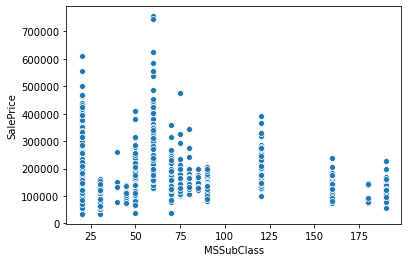

In [19]:
sns.scatterplot(train.MSSubClass, train.SalePrice)

In [20]:
train.MSSubClass.value_counts()/len(train.MSSubClass)*100

20     36.712329
60     20.479452
50      9.863014
120     5.958904
30      4.726027
160     4.315068
70      4.109589
80      3.972603
90      3.561644
190     2.054795
85      1.369863
75      1.095890
45      0.821918
180     0.684932
40      0.273973
Name: MSSubClass, dtype: float64

In [21]:
train.loc[(train["MSSubClass"] != 20) & (train["MSSubClass"] != 50) & (train["MSSubClass"] != 60), 'MSSubClass'] = 'Other'

test.loc[(test["MSSubClass"] != 20) & (test["MSSubClass"] != 50) & (test["MSSubClass"] != 60), 'MSSubClass'] = 'Other'

train["MSSubClass"] = train["MSSubClass"].astype('category')
test["MSSubClass"] = test["MSSubClass"].astype('category')

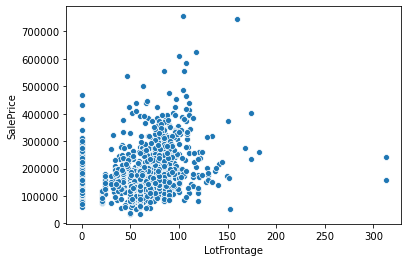

In [22]:
sns.scatterplot(train.LotFrontage, train.SalePrice)

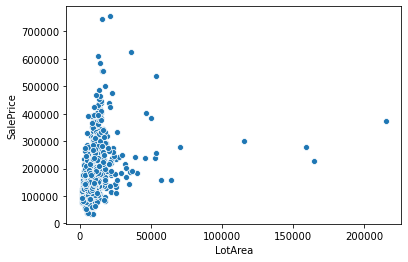

In [23]:
sns.scatterplot(train.LotArea, train.SalePrice)

In [24]:
train.LotShape.value_counts()/len(train.LotShape)*100

Reg    63.356164
IR1    33.150685
IR2     2.808219
IR3     0.684932
Name: LotShape, dtype: float64

In [25]:
train["LotShape"] = train["LotShape"].astype('category')
test["LotShape"] = test["LotShape"].astype('category')

In [26]:
train.Neighborhood.value_counts()/len(train.Neighborhood)*100

NAmes      15.410959
CollgCr    10.273973
OldTown     7.739726
Edwards     6.849315
Somerst     5.890411
Gilbert     5.410959
NridgHt     5.273973
Sawyer      5.068493
NWAmes      5.000000
SawyerW     4.041096
BrkSide     3.972603
Crawfor     3.493151
Mitchel     3.356164
NoRidge     2.808219
Timber      2.602740
IDOTRR      2.534247
ClearCr     1.917808
StoneBr     1.712329
SWISU       1.712329
MeadowV     1.164384
Blmngtn     1.164384
BrDale      1.095890
Veenker     0.753425
NPkVill     0.616438
Blueste     0.136986
Name: Neighborhood, dtype: float64

In [27]:
train.loc[(train["Neighborhood"] != 'NAmes') & (train["Neighborhood"] != 'CollgCr') & (train["Neighborhood"] != 'OldTown') & 
          (train["Neighborhood"] != 'Edwards') & (train["Neighborhood"] != 'Somerst') & (train["Neighborhood"] != 'Gilbert') & 
          (train["Neighborhood"] != 'NridgHt') & (train["Neighborhood"] != 'Sawyer') & (train["Neighborhood"] != 'NWAmes'), 
          'Neighborhood'] = 'Other'

test.loc[(test["Neighborhood"] != 'NAmes') & (test["Neighborhood"] != 'CollgCr') & (test["Neighborhood"] != 'OldTown') & 
         (test["Neighborhood"] != 'Edwards') & (test["Neighborhood"] != 'Somerst') & (test["Neighborhood"] != 'Gilbert') & 
         (test["Neighborhood"] != 'NridgHt') & (test["Neighborhood"] != 'Sawyer') & (test["Neighborhood"] != 'NWAmes'), 
         'Neighborhood'] = 'Other'

train["Neighborhood"] = train["Neighborhood"].astype('category')
test["Neighborhood"] = test["Neighborhood"].astype('category')

In [28]:
train.HouseStyle.value_counts()/len(train.HouseStyle)*100

1Story    49.726027
2Story    30.479452
1.5Fin    10.547945
SLvl       4.452055
SFoyer     2.534247
1.5Unf     0.958904
2.5Unf     0.753425
2.5Fin     0.547945
Name: HouseStyle, dtype: float64

In [29]:
train["HouseStyle"] = train["HouseStyle"].astype('category')
test["HouseStyle"] = test["HouseStyle"].astype('category')

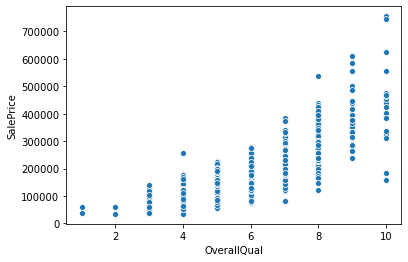

In [30]:
sns.scatterplot(train.OverallQual, train.SalePrice)

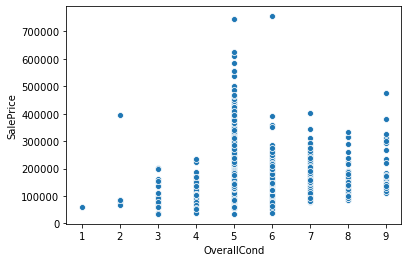

In [31]:
sns.scatterplot(train.OverallCond, train.SalePrice)

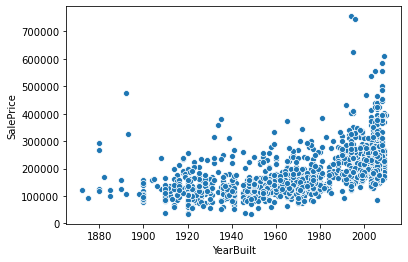

In [32]:
sns.scatterplot(train.YearBuilt, train.SalePrice)

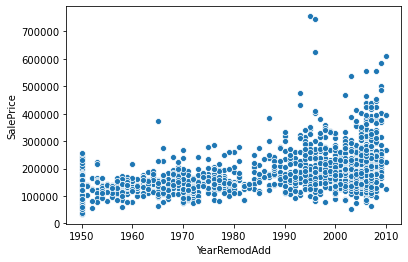

In [33]:
sns.scatterplot(train.YearRemodAdd, train.SalePrice)

In [34]:
train.Exterior1st.value_counts()/len(train.Exterior1st)*100

VinylSd    35.273973
HdBoard    15.205479
MetalSd    15.068493
Wd Sdng    14.109589
Plywood     7.397260
CemntBd     4.178082
BrkFace     3.424658
WdShing     1.780822
Stucco      1.712329
AsbShng     1.369863
BrkComm     0.136986
Stone       0.136986
AsphShn     0.068493
CBlock      0.068493
ImStucc     0.068493
Name: Exterior1st, dtype: float64

In [35]:
train.loc[(train["Exterior1st"] != 'VinylSd') & (train["Exterior1st"] != 'HdBoard') & (train["Exterior1st"] != 'MetalSd') & 
          (train["Exterior1st"] != 'Wd Sdng') & (train["Exterior1st"] != 'Plywood') & (train["Exterior1st"] != 'CemntBd') & 
          (train["Exterior1st"] != 'BrkFace'), 'Exterior1st'] = 'Other'

test.loc[(test["Exterior1st"] != 'VinylSd') & (test["Exterior1st"] != 'HdBoard') & (test["Exterior1st"] != 'MetalSd') & 
         (test["Exterior1st"] != 'Wd Sdng') & (test["Exterior1st"] != 'Plywood') & (test["Exterior1st"] != 'CemntBd') & 
         (test["Exterior1st"] != 'BrkFace'), 'Exterior1st'] = 'Other'

train["Exterior1st"] = train["Exterior1st"].astype('category')
test["Exterior1st"] = test["Exterior1st"].astype('category')

In [36]:
train.Exterior2nd.value_counts()/len(train.Exterior2nd)*100

VinylSd    34.520548
MetalSd    14.657534
HdBoard    14.178082
Wd Sdng    13.493151
Plywood     9.726027
CmentBd     4.109589
Wd Shng     2.602740
Stucco      1.780822
BrkFace     1.712329
AsbShng     1.369863
ImStucc     0.684932
Brk Cmn     0.479452
Stone       0.342466
AsphShn     0.205479
CBlock      0.068493
Other       0.068493
Name: Exterior2nd, dtype: float64

In [37]:
train.loc[(train["Exterior2nd"] != 'VinylSd') & (train["Exterior2nd"] != 'HdBoard') & (train["Exterior2nd"] != 'MetalSd') & 
          (train["Exterior2nd"] != 'Wd Sdng') & (train["Exterior2nd"] != 'Plywood') & (train["Exterior2nd"] != 'CemntBd'), 
          'Exterior2nd'] = 'Other'

test.loc[(test["Exterior2nd"] != 'VinylSd') & (test["Exterior2nd"] != 'HdBoard') & (test["Exterior2nd"] != 'MetalSd') & 
         (test["Exterior2nd"] != 'Wd Sdng') & (test["Exterior2nd"] != 'Plywood') & (test["Exterior2nd"] != 'CemntBd'), 
         'Exterior2nd'] = 'Other'

train["Exterior2nd"] = train["Exterior2nd"].astype('category')
test["Exterior2nd"] = test["Exterior2nd"].astype('category')

In [38]:
train.MasVnrType.value_counts()/len(train.MasVnrType)*100

None       59.178082
BrkFace    30.479452
Stone       8.767123
BrkCmn      1.027397
Other       0.547945
Name: MasVnrType, dtype: float64

In [39]:
train["MasVnrType"] = train["MasVnrType"].astype('category')
test["MasVnrType"] = test["MasVnrType"].astype('category')

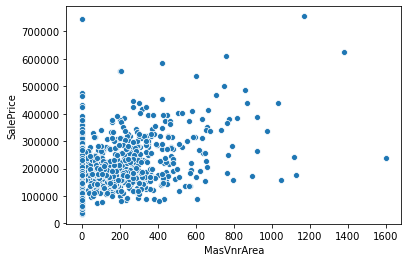

In [40]:
sns.scatterplot(train.MasVnrArea, train.SalePrice)

In [41]:
train.ExterQual.value_counts()/len(train.ExterQual)*100

TA    62.054795
Gd    33.424658
Ex     3.561644
Fa     0.958904
Name: ExterQual, dtype: float64

In [42]:
train["ExterQual"] = train["ExterQual"].astype('category')
test["ExterQual"] = test["ExterQual"].astype('category')

In [43]:
train.Foundation.value_counts()/len(train.Foundation)*100

PConc     44.315068
CBlock    43.424658
BrkTil    10.000000
Slab       1.643836
Stone      0.410959
Wood       0.205479
Name: Foundation, dtype: float64

In [44]:
train["Foundation"] = train["Foundation"].astype('category')
test["Foundation"] = test["Foundation"].astype('category')

In [45]:
train.BsmtQual.value_counts()/len(train.BsmtQual)*100

TA       44.452055
Gd       42.328767
Ex        8.287671
Other     2.534247
Fa        2.397260
Name: BsmtQual, dtype: float64

In [46]:
train["BsmtQual"] = train["BsmtQual"].astype('category')
test["BsmtQual"] = test["BsmtQual"].astype('category')

In [47]:
train.BsmtExposure.value_counts()/len(train.BsmtExposure)*100

No       65.273973
Av       15.136986
Gd        9.178082
Mn        7.808219
Other     2.602740
Name: BsmtExposure, dtype: float64

In [48]:
train["BsmtExposure"] = train["BsmtExposure"].astype('category')
test["BsmtExposure"] = test["BsmtExposure"].astype('category')

In [49]:
train.BsmtFinType1.value_counts()/len(train.BsmtFinType1)*100

Unf      29.452055
GLQ      28.630137
ALQ      15.068493
BLQ      10.136986
Rec       9.109589
LwQ       5.068493
Other     2.534247
Name: BsmtFinType1, dtype: float64

In [50]:
train["BsmtFinType1"] = train["BsmtFinType1"].astype('category')
test["BsmtFinType1"] = test["BsmtFinType1"].astype('category')

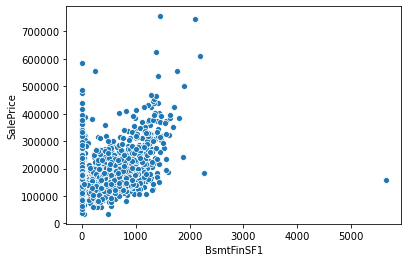

In [51]:
sns.scatterplot(train.BsmtFinSF1, train.SalePrice)

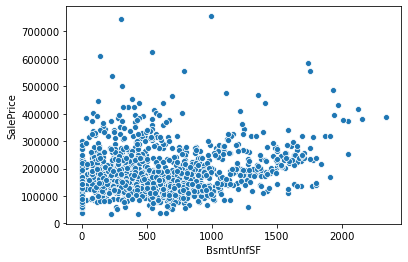

In [52]:
sns.scatterplot(train.BsmtUnfSF, train.SalePrice)

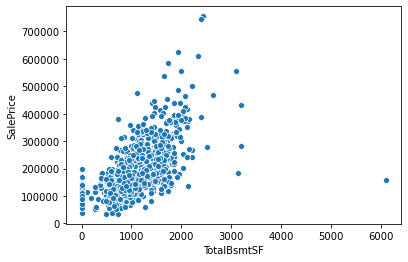

In [53]:
sns.scatterplot(train.TotalBsmtSF, train.SalePrice)

In [54]:
train.HeatingQC.value_counts()/len(train.HeatingQC)*100

Ex    50.753425
TA    29.315068
Gd    16.506849
Fa     3.356164
Po     0.068493
Name: HeatingQC, dtype: float64

In [55]:
train["HeatingQC"] = train["HeatingQC"].astype('category')
test["HeatingQC"] = test["HeatingQC"].astype('category')

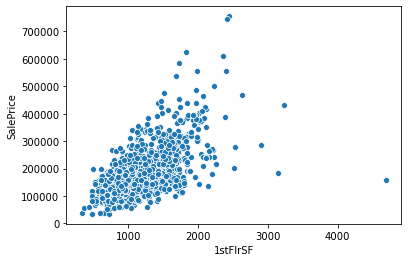

In [56]:
sns.scatterplot(train['1stFlrSF'], train.SalePrice)

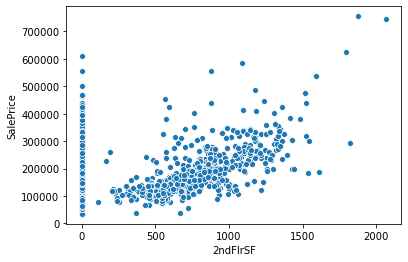

In [57]:
sns.scatterplot(train['2ndFlrSF'], train.SalePrice)

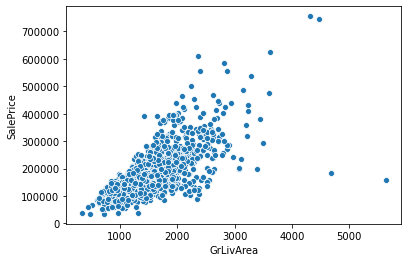

In [58]:
sns.scatterplot(train.GrLivArea, train.SalePrice)

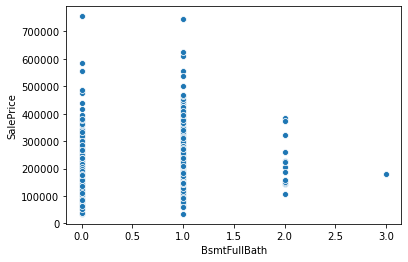

In [59]:
sns.scatterplot(train.BsmtFullBath, train.SalePrice)

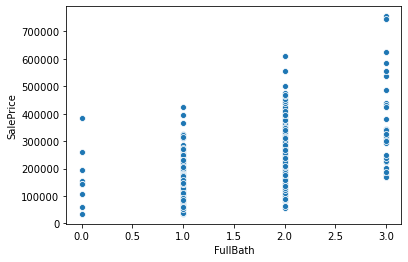

In [60]:
sns.scatterplot(train.FullBath, train.SalePrice)

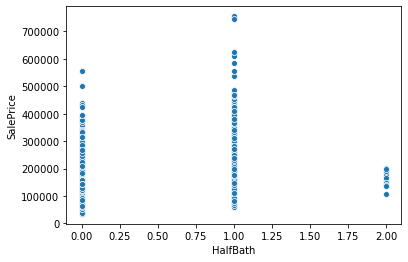

In [61]:
sns.scatterplot(train.HalfBath, train.SalePrice)

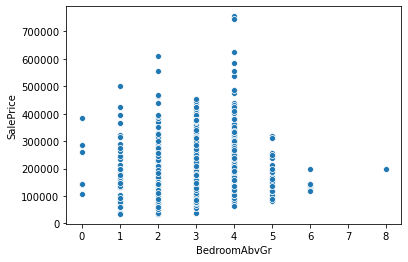

In [62]:
sns.scatterplot(train.BedroomAbvGr, train.SalePrice)

In [63]:
train.KitchenQual.value_counts()/len(train.KitchenQual)*100

TA    50.342466
Gd    40.136986
Ex     6.849315
Fa     2.671233
Name: KitchenQual, dtype: float64

In [64]:
train["KitchenQual"] = train["KitchenQual"].astype('category')
test["KitchenQual"] = test["KitchenQual"].astype('category')

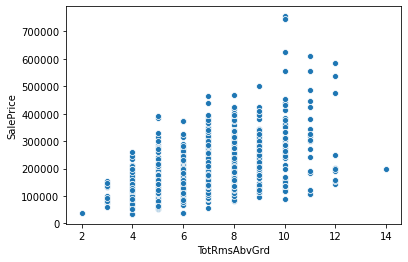

In [65]:
sns.scatterplot(train.TotRmsAbvGrd, train.SalePrice)

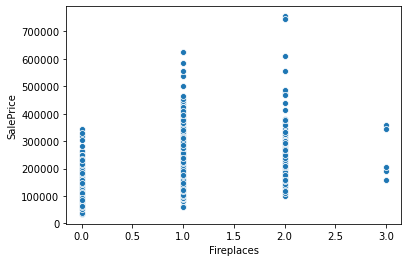

In [66]:
sns.scatterplot(train.Fireplaces, train.SalePrice)

In [67]:
train.FireplaceQu.value_counts()/len(train.FireplaceQu)*100

Other    47.260274
Gd       26.027397
TA       21.438356
Fa        2.260274
Ex        1.643836
Po        1.369863
Name: FireplaceQu, dtype: float64

In [68]:
train["FireplaceQu"] = train["FireplaceQu"].astype('category')
test["FireplaceQu"] = test["FireplaceQu"].astype('category')

In [69]:
train.GarageType.value_counts()/len(train.GarageType)*100

Attchd     59.589041
Detchd     26.506849
BuiltIn     6.027397
Other       5.547945
Basment     1.301370
CarPort     0.616438
2Types      0.410959
Name: GarageType, dtype: float64

In [70]:
train["GarageType"] = train["GarageType"].astype('category')
test["GarageType"] = test["GarageType"].astype('category')

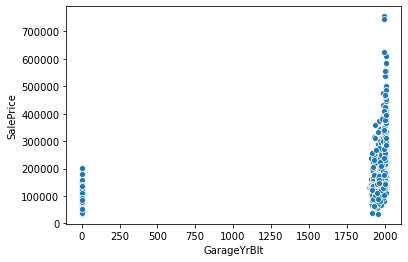

In [71]:
sns.scatterplot(train.GarageYrBlt, train.SalePrice)

In [72]:
train.GarageFinish.value_counts()/len(train.GarageFinish)*100

Unf      41.438356
RFn      28.904110
Fin      24.109589
Other     5.547945
Name: GarageFinish, dtype: float64

In [73]:
train["GarageFinish"] = train["GarageFinish"].astype('category')
test["GarageFinish"] = test["GarageFinish"].astype('category')

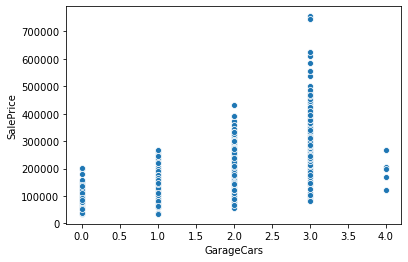

In [74]:
sns.scatterplot(train.GarageCars, train.SalePrice)

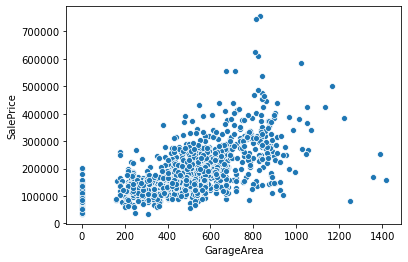

In [75]:
sns.scatterplot(train.GarageArea, train.SalePrice)

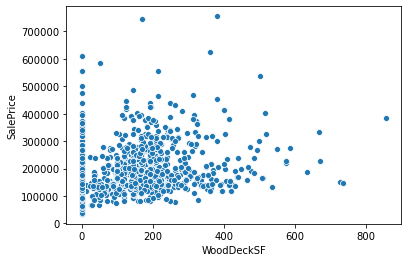

In [76]:
sns.scatterplot(train.WoodDeckSF, train.SalePrice)

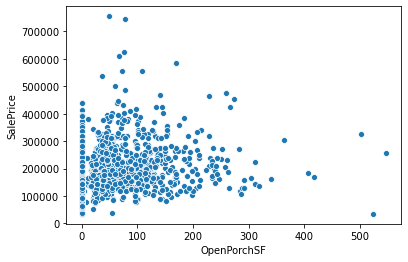

In [77]:
sns.scatterplot(train.OpenPorchSF, train.SalePrice)

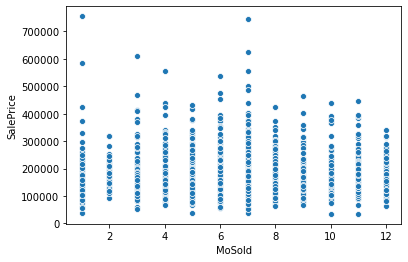

In [78]:
sns.scatterplot(train.MoSold, train.SalePrice)

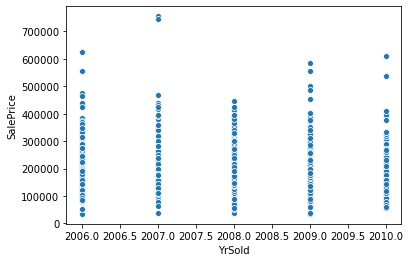

In [79]:
sns.scatterplot(train.YrSold, train.SalePrice)

In [80]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 44 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   MSSubClass    1460 non-null   category
 1   LotFrontage   1460 non-null   float64 
 2   LotArea       1460 non-null   int64   
 3   LotShape      1460 non-null   category
 4   Neighborhood  1460 non-null   category
 5   HouseStyle    1460 non-null   category
 6   OverallQual   1460 non-null   int64   
 7   OverallCond   1460 non-null   int64   
 8   YearBuilt     1460 non-null   int64   
 9   YearRemodAdd  1460 non-null   int64   
 10  Exterior1st   1460 non-null   category
 11  Exterior2nd   1460 non-null   category
 12  MasVnrType    1460 non-null   category
 13  MasVnrArea    1460 non-null   float64 
 14  ExterQual     1460 non-null   category
 15  Foundation    1460 non-null   category
 16  BsmtQual      1460 non-null   category
 17  BsmtExposure  1460 non-null   category
 18  BsmtFinT

# One Hot Encoding

In [81]:
for col in train.columns:
    if train[col].dtype.name == 'category':
        dum_df = pd.get_dummies(train[col], columns=col, prefix=col)
        train = train.join(dum_df)
        train.drop(col, axis = 1, inplace=True)
        
        dum_df = pd.get_dummies(test[col], columns=col, prefix=col)
        test = test.join(dum_df)
        test.drop(col, axis = 1, inplace=True)

In [82]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 125 entries, LotFrontage to GarageFinish_Unf
dtypes: float64(3), int64(24), uint8(98)
memory usage: 447.8 KB


# Train Test Split

In [83]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(train.drop(columns = "SalePrice", axis=1), train.loc[:,"SalePrice"], 
                                                    test_size=0.2, random_state=0)

# Model

In [84]:
y_train.head()

618    314813
870    109500
92     163500
817    271000
302    205000
Name: SalePrice, dtype: int64

In [85]:
regr = ElasticNet(alpha=0.5, l1_ratio=1, random_state=0)
regr.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 395631047242.65643, tolerance: 719132949.923008
  positive)


ElasticNet(alpha=0.5, l1_ratio=1, random_state=0)

In [86]:
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(regr, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
scores = abs(scores)
print('Mean MAE: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

Mean MAE: 17939.251 (1992.098)


In [87]:
print(regr.coef_)

[ 3.42034757e+01  3.26222284e-01  1.04094308e+04  6.77377130e+03
  5.30450919e+01  5.68292415e+01  3.09796140e+01  6.63768845e+00
 -3.52029968e+00  2.86748070e+01 -1.55994577e+00  2.27469249e+01
  3.82308073e+01  2.35172045e+03  4.76329149e+03  6.12748451e+03
 -3.71875809e+03  2.05721494e+03  6.76701324e+03 -9.84375136e+00
  6.07212355e+03  1.56187476e+01  1.36665763e+01 -1.30328864e+01
 -4.28345290e+02 -7.45051644e+02  3.58243188e+03  4.63248201e+03
  8.58335585e+03 -9.10803005e+03 -0.00000000e+00  1.04162754e+04
  1.10473430e+04 -2.55578120e+03  9.47793216e+02 -9.14294874e+03
 -2.88335101e+03 -7.35822529e+03 -7.09619329e+03  2.12290992e+04
 -9.24487917e+03  6.90218991e+03 -1.83445384e+03  1.36865521e+04
 -9.03395945e+03  1.67358382e+04  1.44054746e+04 -1.49718001e+04
 -1.07283083e+04 -9.20797203e+03  1.36176659e+04  1.89722092e+04
  1.70823343e+04 -0.00000000e+00  1.26799855e+03 -2.10513238e+03
  8.36807197e+03  1.25430454e+02 -4.99334941e+03 -2.34945816e+03
 -6.23424843e+03  2.01942

# Tuning

In [88]:
param_grid = {
                'alpha'     : [0.1,1,10,0.01],
                'l1_ratio'  :  np.arange(0.40,1.00,0.10),
                'tol'       : [0.0001,0.001]
            }
eNet = ElasticNet(max_iter=10000)
grid_search = GridSearchCV(eNet, 
                           param_grid, 
                           scoring='neg_mean_absolute_error', 
                           return_train_score=True,
                           n_jobs = -1)
grid_search.fit(X_train,y_train)

GridSearchCV(estimator=ElasticNet(max_iter=10000), n_jobs=-1,
             param_grid={'alpha': [0.1, 1, 10, 0.01],
                         'l1_ratio': array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'tol': [0.0001, 0.001]},
             return_train_score=True, scoring='neg_mean_absolute_error')

In [89]:
print("Best parameters : {}".format(grid_search.best_params_))
print("Best cross validation score: {:.2f}".format(grid_search.best_score_))
print("Best estimator: {}".format(grid_search.best_estimator_))

Best parameters : {'alpha': 0.1, 'l1_ratio': 0.6, 'tol': 0.0001}
Best cross validation score: -17502.59
Best estimator: ElasticNet(alpha=0.1, l1_ratio=0.6, max_iter=10000)


In [90]:
results = pd.DataFrame(grid_search.cv_results_)
results.sort_values(['mean_test_score'],ascending = False)[:10]
#results.loc["params", "mean_test_score", "std_test_score"]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_l1_ratio,param_tol,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
4,0.504285,0.071961,0.005508,0.000624,0.1,0.6,0.0001,"{'alpha': 0.1, 'l1_ratio': 0.6, 'tol': 0.0001}",-15360.855213,-19672.451169,...,-17502.589863,1438.744779,1,-16794.623907,-15569.883507,-16265.316455,-16121.841097,-16570.696885,-16264.472370,418.958754
5,0.480731,0.080088,0.005485,0.000542,0.1,0.6,0.001,"{'alpha': 0.1, 'l1_ratio': 0.6, 'tol': 0.001}",-15360.855172,-19672.451286,...,-17502.589900,1438.744816,2,-16794.623887,-15569.883518,-16265.316428,-16121.841085,-16570.696941,-16264.472372,418.958754
2,0.499029,0.098918,0.005166,0.000566,0.1,0.5,0.0001,"{'alpha': 0.1, 'l1_ratio': 0.5, 'tol': 0.0001}",-15351.420083,-19675.797687,...,-17511.380327,1444.507943,3,-16881.366337,-15677.661753,-16345.955169,-16196.382724,-16629.744887,-16346.222174,408.947276
3,0.461905,0.080091,0.005195,0.000642,0.1,0.5,0.001,"{'alpha': 0.1, 'l1_ratio': 0.5, 'tol': 0.001}",-15351.420055,-19675.797765,...,-17511.380353,1444.507965,4,-16881.366316,-15677.661756,-16345.955144,-16196.382715,-16629.744942,-16346.222175,408.947278
6,0.490100,0.086076,0.005340,0.000646,0.1,0.7,0.0001,"{'alpha': 0.1, 'l1_ratio': 0.7, 'tol': 0.0001}",-15391.330839,-19693.071043,...,-17511.838160,1435.751608,5,-16695.380883,-15444.217593,-16189.699503,-16050.808186,-16524.445897,-16180.910413,434.146667
7,0.459751,0.073088,0.005311,0.000628,0.1,0.7,0.001,"{'alpha': 0.1, 'l1_ratio': 0.7, 'tol': 0.001}",-15391.330804,-19693.071182,...,-17511.838218,1435.751644,6,-16695.380853,-15444.217620,-16189.699471,-16050.808178,-16524.445959,-16180.910416,434.146661
0,0.429090,0.115361,0.004363,0.001102,0.1,0.4,0.0001,"{'alpha': 0.1, 'l1_ratio': 0.4, 'tol': 0.0001}",-15345.602380,-19698.015057,...,-17529.106366,1453.773143,7,-16966.557457,-15777.159298,-16415.283669,-16266.727195,-16690.290782,-16423.203680,402.116851
1,0.407986,0.058691,0.004918,0.000894,0.1,0.4,0.001,"{'alpha': 0.1, 'l1_ratio': 0.4, 'tol': 0.001}",-15345.602355,-19698.015102,...,-17529.106385,1453.773155,8,-16966.557436,-15777.159299,-16415.283646,-16266.727187,-16690.290816,-16423.203677,402.116850
8,0.481632,0.097302,0.005159,0.000520,0.1,0.8,0.0001,"{'alpha': 0.1, 'l1_ratio': 0.7999999999999999,...",-15464.844030,-19750.812771,...,-17563.516610,1434.070217,9,-16594.617176,-15306.883635,-16125.549602,-15971.969528,-16506.442782,-16101.092545,459.546313
9,0.466468,0.098369,0.005584,0.000720,0.1,0.8,0.001,"{'alpha': 0.1, 'l1_ratio': 0.7999999999999999,...",-15464.843998,-19750.812916,...,-17563.516676,1434.070250,10,-16594.617136,-15306.883576,-16125.549569,-15971.969518,-16506.442790,-16101.092518,459.546327


In [91]:
scores_mean = np.array(results.mean_test_score).reshape(-1)
scores_std = np.array(results.std_test_score).reshape(-1)
print("mean CV scores for each fold {} ".format(scores_mean))
print("std CV scores for each fold {} ".format(scores_std))

mean CV scores for each fold [-17529.10636595 -17529.10638504 -17511.38032652 -17511.38035269
 -17502.58986277 -17502.5899     -17511.83815982 -17511.83821834
 -17563.5166103  -17563.5166759  -17713.61384911 -17713.61396
 -19104.64094873 -19104.64027523 -18852.00557225 -18852.00552821
 -18586.18369013 -18586.18379904 -18292.17286665 -18292.1730885
 -17964.12769764 -17964.12783491 -17638.03171656 -17638.03206842
 -22446.02279191 -22446.01717117 -22270.44776276 -22270.44073087
 -22028.51666027 -22028.50806811 -21669.19790178 -21669.18734932
 -21067.10327103 -21067.09056568 -19913.34472918 -19913.3280577
 -17830.19704687 -17830.19705197 -17869.45536924 -17869.45537569
 -17914.68521967 -17914.68522778 -17969.03698424 -17969.03698661
 -18036.63015664 -18036.63015852 -18124.22230613 -18124.22230534] 
std CV scores for each fold [1453.77314288 1453.7731547  1444.50794282 1444.50796514 1438.74477926
 1438.74481607 1435.75160814 1435.75164364 1434.07021669 1434.0702504
 1409.81972936 1409.81984

In [92]:
test_pred = grid_search.predict(test.iloc[:,1:])

In [93]:
test_pred

array([128734.84512919, 187123.60581306, 181861.81758294, ...,
       190599.04714294, 106384.54622123, 240178.27194722])

In [94]:
my_submission = pd.DataFrame(data={'Id': test['Id'].values, 'SalePrice': test_pred.reshape(-1, )})
my_submission.head()

my_submission.to_csv(r'submission.csv', index=False)

In [95]:
my_submission.head()

,Id,SalePrice
0,1461,128734.845129
1,1462,187123.605813
2,1463,181861.817583
3,1464,204748.746856
4,1465,184552.240332


In [96]:
my_submission.describe()

,Id,SalePrice
count,1459.000000,1459.000000
mean,2190.000000,179573.716243
std,421.321334,67536.441697
min,1461.000000,-7982.895558
25%,1825.500000,133131.666098
50%,2190.000000,169390.505624
75%,2554.500000,216528.442753
max,2919.000000,663259.070180
